## SIMULATION D'EQUATION DIFFERENTIELLE PATIELLE
### APPLICATION

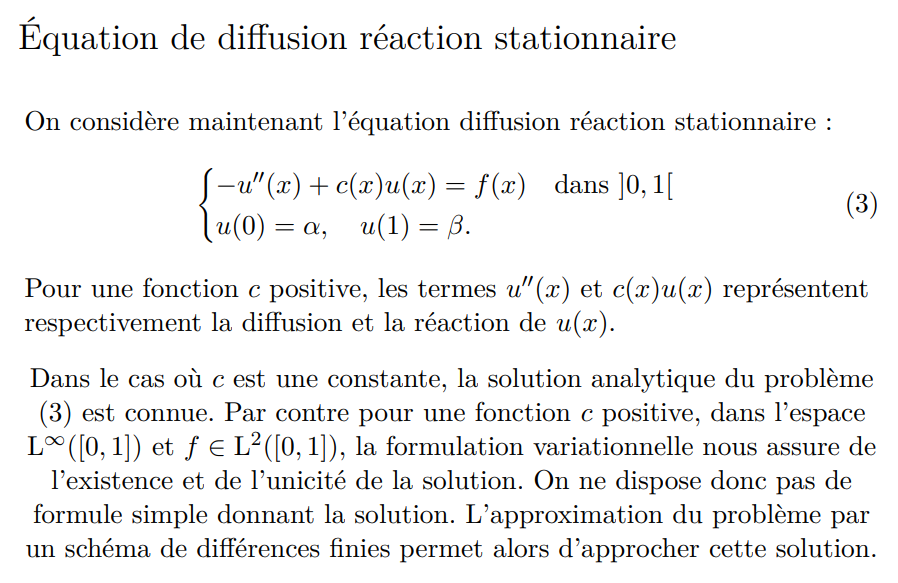

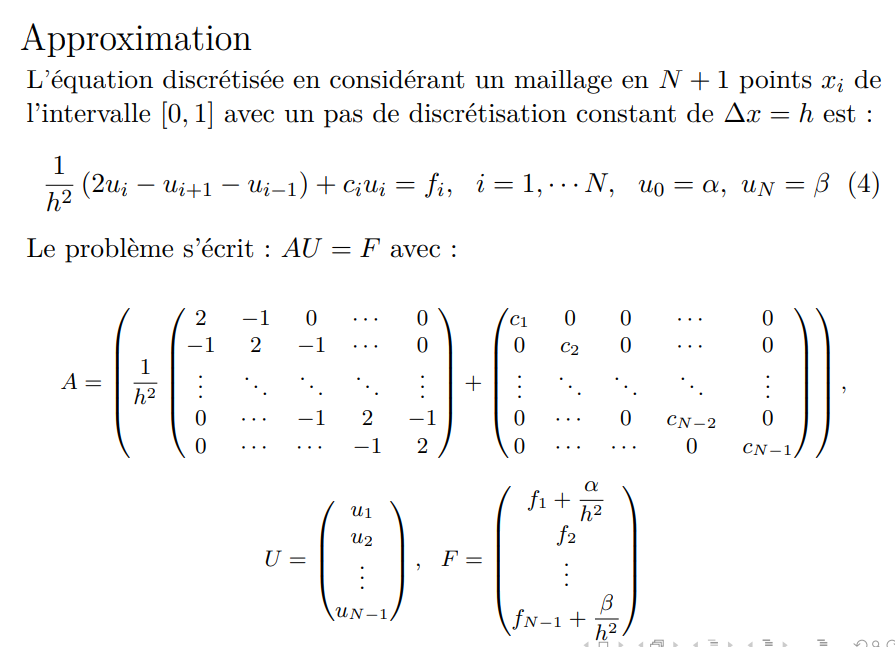

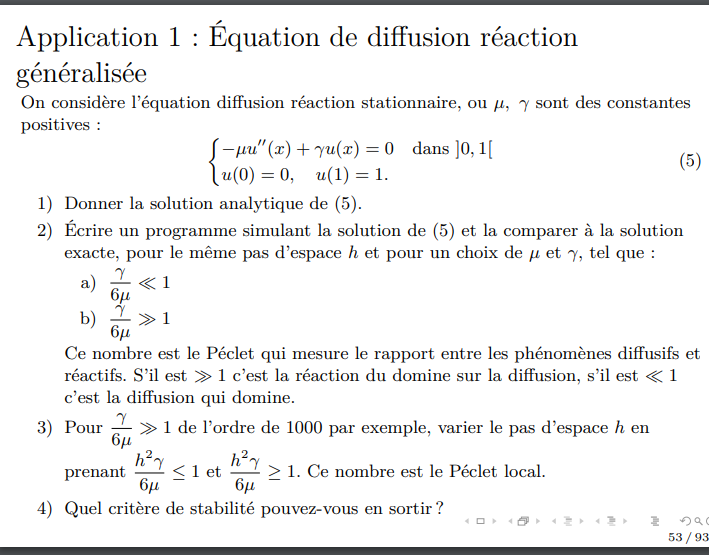

#### 1. La solution analytique de (5) 

In [71]:
from sympy import symbols, Function, Eq, dsolve, sin, cos, exp
from sympy.abc import x, u, g 
import numpy as np
import matplotlib.pyplot as plt
import scipy.sparse as sp
from scipy.sparse.linalg import spsolve
from scipy.linalg import norm

In [72]:
y = Function('y')

In [73]:
edp = Eq(-u*y(x).diff(x, 2) + g*y(x).diff(x) + 2*y(x), 0)
solution_analytique = dsolve(edp, ics={y(0): 0, y(1): 1})
print("Solution particulière de l'EDO avec condition initiale:\n", solution_analytique)
print("\n")
solution_analytique

Solution particulière de l'EDO avec condition initiale:
 Eq(y(x), -exp(sqrt(g**2 + 8*u)/(2*u))*exp(x*(g - sqrt(g**2 + 8*u))/(2*u))/(exp(g/(2*u))*exp(sqrt(g**2 + 8*u)/u) - exp(g/(2*u))) + exp(sqrt(g**2 + 8*u)/(2*u))*exp(x*(g + sqrt(g**2 + 8*u))/(2*u))/(exp(g/(2*u))*exp(sqrt(g**2 + 8*u)/u) - exp(g/(2*u))))




Eq(y(x), -exp(sqrt(g**2 + 8*u)/(2*u))*exp(x*(g - sqrt(g**2 + 8*u))/(2*u))/(exp(g/(2*u))*exp(sqrt(g**2 + 8*u)/u) - exp(g/(2*u))) + exp(sqrt(g**2 + 8*u)/(2*u))*exp(x*(g + sqrt(g**2 + 8*u))/(2*u))/(exp(g/(2*u))*exp(sqrt(g**2 + 8*u)/u) - exp(g/(2*u))))

#### 2.Simulation de la solution de (5) 

a. $$ \frac{g}{6u} \ll 1$$ 

In [139]:
NX = 10
val_diags = [-np.ones(NX-2), 2*np.ones(NX-2), -np.ones(NX-2)]
val_diags

[array([-1., -1., -1., -1., -1., -1., -1., -1.]),
 array([2., 2., 2., 2., 2., 2., 2., 2.]),
 array([-1., -1., -1., -1., -1., -1., -1., -1.])]

In [140]:
positions = np.array ([ -1 ,0 ,1])
positions

array([-1,  0,  1])

In [141]:
A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
print(A)


<DIAgonal sparse matrix of dtype 'float64'
	with 22 stored elements (3 diagonals) and shape (8, 8)>
  Coords	Values
  (1, 0)	-1.0
  (2, 1)	-1.0
  (3, 2)	-1.0
  (4, 3)	-1.0
  (5, 4)	-1.0
  (6, 5)	-1.0
  (7, 6)	-1.0
  (0, 0)	2.0
  (1, 1)	2.0
  (2, 2)	2.0
  (3, 3)	2.0
  (4, 4)	2.0
  (5, 5)	2.0
  (6, 6)	2.0
  (7, 7)	2.0
  (0, 1)	-1.0
  (1, 2)	-1.0
  (2, 3)	-1.0
  (3, 4)	-1.0
  (4, 5)	-1.0
  (5, 6)	-1.0
  (6, 7)	-1.0


In [123]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas
gamma = g = 0.01
mu = u = 1
alpha = 0
beta = 1
# gamma / 6 * mu = 0.00166666666 << 1


In [124]:
#####################FONCTIONS##################
# DEFINITION DE LA FONCTION SOURCE F
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
        np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) + 
        np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u)))
    )
Uex = np.vectorize ( func2 )


C:\Users\User\AppData\Local\Temp\ipykernel_15460\495262795.py:23: SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
  Uint = spsolve(A , F )


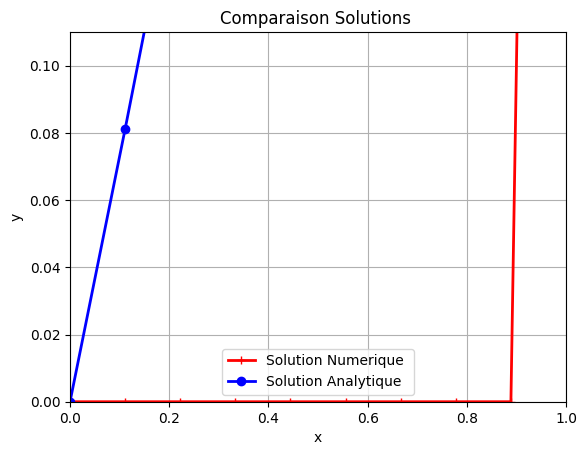

In [ ]:
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

########################"Avertissement"############################
# C:\Users\User\AppData\Local\Temp\ipykernel_15460\850092065.py:17: 
# SparseEfficiencyWarning: spsolve requires A be CSC or CSR matrix format
# signifie que la fonction spsolve de scipy.sparse.linalg nécessite que la matrice A
# soit au format CSC (Compressed Sparse Column) ou CSR (Compressed Sparse Row) pour des 
# raisons d'efficacité. 


#### Changement du format de la matrice A

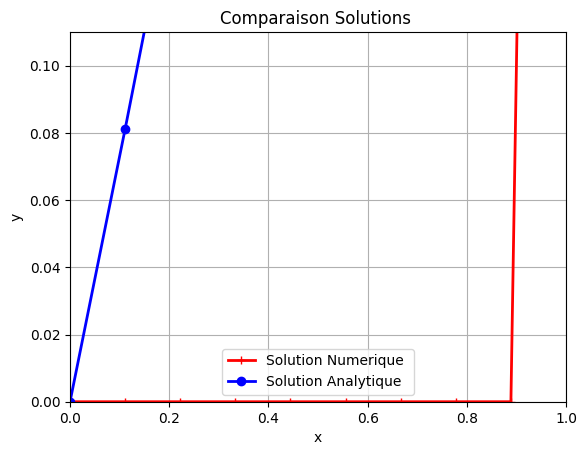

In [126]:
from scipy.sparse import csc_matrix, csr_matrix
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

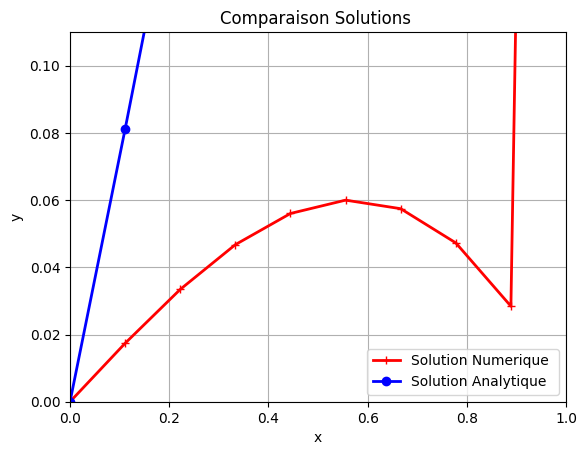

In [127]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas
gamma = g = 0.01
mu = u = 1
alpha = 0
beta = 1
# gamma / 6 * mu = 0.006 << 1

#####################FONCTIONS##################
# Fonction sinusoïdale : une source qui varie de manière sinusoïdale.
# DEFINITION DE LA FONCTION SOURCE F
def func1(x):  
    return np.sin(x)
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
        np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) + 
        np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u)))
    )
Uex = np.vectorize ( func2 )

from scipy.sparse import csc_matrix, csr_matrix
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()


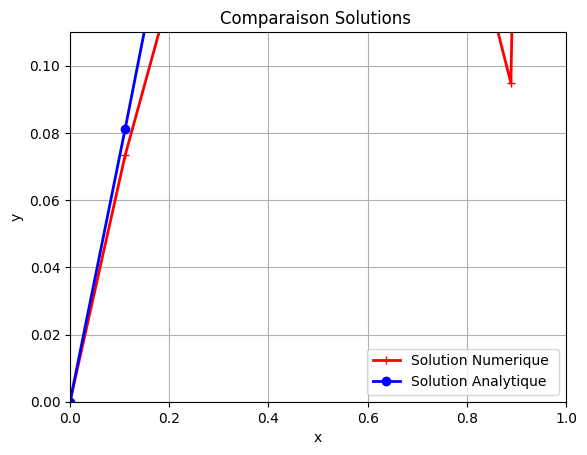

In [129]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas
gamma = g = 0.01
mu = u = 1
alpha = 0
beta = 1
# gamma / 6 * mu = 0.00166666666<< 1
#####################FONCTIONS##################
# Fonction exponentielle : une source qui varie exponentiellement.
# DEFINITION DE LA FONCTION SOURCE F
def func1(x):  
    return np.exp(x)
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
        np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) + 
        np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u)))
    )
Uex = np.vectorize ( func2 )

#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

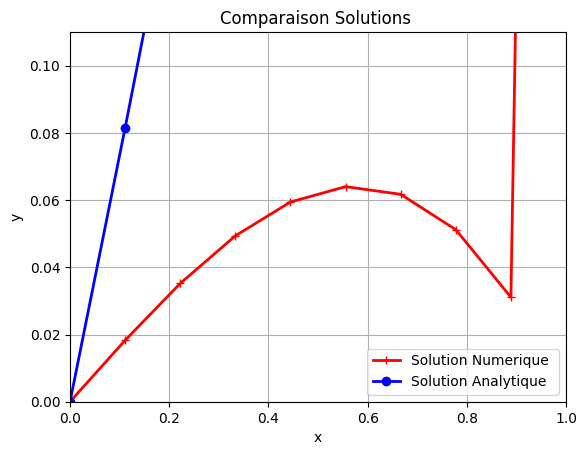

In [135]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas
gamma = g = 0.0001
mu = u = 1
alpha = 0
beta = 1
# gamma / 6 * mu = 0.00166666666 << 1
# #####################FONCTIONS##################
# Fonction linéaire : une source qui varie linéairement avec x.
# DEFINITION DE LA FONCTION SOURCE F
def func1(x):  
    return x
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
        np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) + 
        np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u)))
    )
Uex = np.vectorize ( func2 )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return ( U )
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

b. $$ \frac{g}{6u} \gg 1$$

C:\Users\User\AppData\Local\Temp\ipykernel_15460\2064501679.py:19: RuntimeWarning: overflow encountered in exp
  -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\2064501679.py:20: RuntimeWarning: overflow encountered in exp
  np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\2064501679.py:21: RuntimeWarning: overflow encountered in exp
  np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) +
C:\Users\User\AppData\Local\Temp\ipykernel_15460\2064501679.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\2064501679.py:22: RuntimeWarning: overflow encountered in exp
  np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\2064501679.py:23: RuntimeWarning: overflow encountered in exp
  np.e

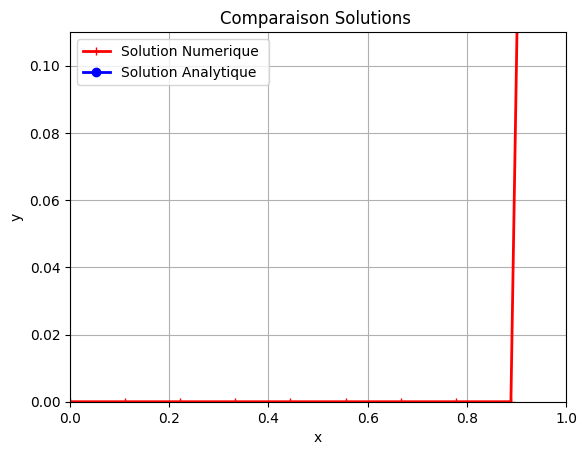

In [132]:
#####################CONSTANTES##################
NX = 10 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.0001
alpha = 0
beta = 1
# gamma / 6 * mu = 998 >> 1
# #####################FONCTIONS##################
# Fonction linéaire : une source qui varie linéairement avec x.
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
        np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) + 
        np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u)))
    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()

#### 3. Pour $$ \frac{g}{6u} \gg 1 $$ de l'ordre 1000, 
####  Variation du pas d'espace h en prenant :
$$ \frac{h^2 \cdot g}{6 \cdot u} \leq 1 $$ 
$$ \frac{h^2 \cdot g}{6 \cdot u} \geq 1 $$


In [ ]:
# h²g / 6u <= 1

C:\Users\User\AppData\Local\Temp\ipykernel_15460\794668851.py:19: RuntimeWarning: overflow encountered in exp
  -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\794668851.py:20: RuntimeWarning: overflow encountered in exp
  np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\794668851.py:21: RuntimeWarning: overflow encountered in exp
  np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) +
C:\Users\User\AppData\Local\Temp\ipykernel_15460\794668851.py:20: RuntimeWarning: invalid value encountered in scalar subtract
  np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\794668851.py:22: RuntimeWarning: overflow encountered in exp
  np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
C:\Users\User\AppData\Local\Temp\ipykernel_15460\794668851.py:23: RuntimeWarning: overflow encountered in exp
  np.exp(np.

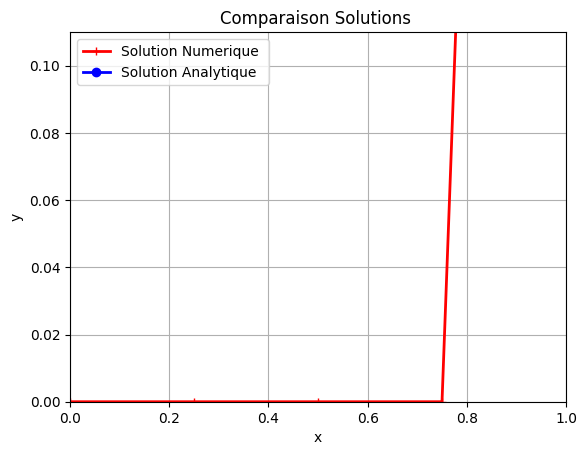

In [ ]:
#####################CONSTANTES##################
NX = 2 # nbre de noeuds
x = np.linspace (0.0 ,1 , NX )
h = dx = 1/( NX -1) # Pas d'espace
gamma = g = 1
mu = u = 0.00001
alpha = 0
beta = 1
# gamma / 6 * mu = 600 >> 1
# #####################FONCTIONS##################
# Fonction linéaire : une source qui varie linéairement avec x.
def func1(x):  
    return 0
f = np.vectorize ( func1 )
# DEFINITION DE LA SOLUTION EXACTE
def func2 ( x ):
    return (
        -np.exp(np.sqrt(g**2 + 8*u)/(2*u))*
        np.exp(x*(g - np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u))) + 
        np.exp(np.sqrt(g**2 + 8*u)/(2*u))*np.exp(x*(g + np.sqrt(g**2 + 8*u))/(2*u))/(np.exp(g/(2*u))*
        np.exp(np.sqrt(g**2 + 8*u)/u) - np.exp(g/(2*u)))
    )
#%% Calcul de la Solution Discrete
def U_discret (x , NX , dx , f ):
    U = np.zeros (( NX ))
    # Conditions limites
    U [0] = 0
    U [-1] = 1 
    # Conditions limites 
# Calcul de F = 1/h² * f(x)
    F = ( dx**2)* f ( x )
    # F[f1 + alpha/h², ... , f(N-1) + beta/h²]
    #  or alpha = 0 , beta = 1 et N = 10
    #  donc F[f1, ... , f9 + 1/h²]
    # H = (NX-1) + 1/( dx**2) = 9
    F[0] = f(x[0]) + alpha / h**2
    F[-1] = f(x[-1]) + beta / h**2
    F = F [1: (NX-1)]
# Calcul de la matrice A
    val_diags = [ - np.ones ( NX-2) ,2* np.ones ( NX -2) , - np.ones ( NX -2)]
    positions = np.array ([ -1 ,0 ,1])
    A = sp.dia_matrix ( ( val_diags , positions ) , shape =( NX -2 , NX -2))
    ########################## "format CSC" ##############################
    # A = csc_matrix(A)
    A = csr_matrix(A)
# Résolution de AU = F
    Uint = spsolve(A , F )
    U [1: NX-1] = Uint
    return (U)
#%% # AFFICHAGE DES SOLUTIONS DISCRETES ET EXACTES COMPAREES
U = U_discret (x , NX , dx , f )
Uexact = Uex ( x )
fig , ax = plt.subplots (1)
ax.plot (x , U , 'r-+', lw =2 , label ='Solution Numerique ')
ax.plot (x , Uexact ,'b-o', lw =2 , label ='Solution Analytique ')
ax.set_xlabel ('x') ; ax.set_ylabel ('y') 
ax.set_xlim ([0 , 1])
ax.set_ylim ([0 , 0.11])
ax.set_title ('Comparaison Solutions ')
ax.legend (); ax.grid ()
